# Import libraries

In [ ]:
import pandas as pd
import numpy as np

from collections import Counter

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

!pip install pytorch-crf
from torchcrf import CRF

In [ ]:
df = pd.read_csv("/content/sample_data/BoroPOStag.csv", low_memory=False)

print(df.shape)
df.head()

(6000, 159)


,ID\tValue,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 149,Unnamed: 150,Unnamed: 151,Unnamed: 152,Unnamed: 153,Unnamed: 154,Unnamed: 155,Unnamed: 156,Unnamed: 157,Unnamed: 158
0,BDHED1\tदेहास्रि\N_NN,होननानै\V_VM,बुंब्ला\V_VM,गोरों\N_NN,गोराफोरा\N_NN,गुबुन\JJ,गुबुन\JJ,आयदायाव\N_NN,साननोगोनां\V_VM,जायो\V_VM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BDHED10\tहोमब्लासो\CC_CCS,जों\PR_PRP,माहारि\N_NN,हान्जा\N_NN,फारसेबो\N_NST,देहास्रि\N_NN,गोगो\JJ,होनजागोन\V_VM,।\RD_PUNC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BDHED100\tखिनानै\V_VM,फैब्ला\V_VM,आखायखौ\N_NN,साबोनजों\N_NN,सुनांगौ\V_VM,।\RD_PUNC,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BDHED1000\tगान्दुनि\N_NN,जिआ\N_NN,साफा\JJ,जानाया\V_VM,मोजां\JJ,।\RD_PUNC,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BDHED101\tमैला-मैलि\N_NN,गैयै\RB,जानांगौ\V_VM,।\RD_PUNC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Parsing the data

In [ ]:
sentences = []
tags = []

for _, row in df.iterrows():

    words = []
    pos_tags = []

    for i, cell in enumerate(row):

        if pd.isna(cell):
            continue

        cell = str(cell)

        # First column contains sentence id
        if i == 0:
            if "\t" in cell:
                cell = cell.split("\t", 1)[1]

        if "\\" not in cell:
            continue

        word, tag = cell.rsplit("\\", 1)

        words.append(word.strip())
        pos_tags.append(tag.strip())

    if len(words) > 0:
        sentences.append(words)
        tags.append(pos_tags)

print(len(sentences))

6000


Statistics

In [ ]:
print("Total Sentences :", len(sentences))

total_words = sum(len(s) for s in sentences)

print("Total Words :", total_words)

print("Average Sentence Length :", total_words/len(sentences))

Total Sentences : 6000
Total Words : 90560
Average Sentence Length : 15.093333333333334


In [ ]:
# Number of unique POS tags
print("Number of Unique POS Tags:", len(tag_counter))

# List all unique tags
print("\nUnique POS Tags:")
for tag in sorted(tag_counter.keys()):
    print(tag)

# Frequency of each tag
print("\nTag Frequencies:")
for tag, count in sorted(tag_counter.items()):
    print(f"{tag:10} : {count}")

Number of Unique POS Tags: 35

Unique POS Tags:
CC_CCD
CC_CCS
DM_DMD
DM_DMI
DM_DMQ
DM_DMR
JJ
N_NN
N_NNP
N_NST
PR_PRC
PR_PRF
PR_PRI
PR_PRL
PR_PRP
PR_PRQ
PSP
QT_QTC
QT_QTF
QT_QTO
RB
RD_ECH
RD_PUNC
RD_RDF
RD_SYM
RD_UNK
RP_INJ
RP_INTF
RP_NEG
RP_RPD
V_VAUX
V_VAUX_VF
V_VM
V_VM_VF
V_VM_VNF

Tag Frequencies:
CC_CCD     : 2458
CC_CCS     : 478
DM_DMD     : 2303
DM_DMI     : 165
DM_DMQ     : 114
DM_DMR     : 15
JJ         : 5351
N_NN       : 23251
N_NNP      : 9797
N_NST      : 3375
PR_PRC     : 61
PR_PRF     : 272
PR_PRI     : 410
PR_PRL     : 71
PR_PRP     : 1219
PR_PRQ     : 111
PSP        : 1945
QT_QTC     : 2504
QT_QTF     : 570
QT_QTO     : 573
RB         : 1788
RD_ECH     : 373
RD_PUNC    : 13276
RD_RDF     : 1473
RD_SYM     : 382
RD_UNK     : 402
RP_INJ     : 10
RP_INTF    : 91
RP_NEG     : 103
RP_RPD     : 100
V_VAUX     : 169
V_VAUX_VF  : 2
V_VM       : 17338
V_VM_VF    : 2
V_VM_VNF   : 8


# Building Voca

In [ ]:
word_counter = Counter()
char_counter = Counter()
tag_counter = Counter()

for sent, tag_seq in zip(sentences, tags):

    word_counter.update(sent)

    tag_counter.update(tag_seq)

    for word in sent:
        char_counter.update(list(word))

Mappings

In [ ]:
word2id = {
    "<PAD>":0,
    "<UNK>":1
}

for word in word_counter:
    word2id[word] = len(word2id)

tag2id = {"<PAD>":0}

for tag in sorted(tag_counter):
    tag2id[tag] = len(tag2id)

char2id = {
    "<PAD>":0,
    "<UNK>":1
}

for ch in char_counter:
    char2id[ch] = len(char2id)

In [ ]:
print("Number of Unique POS Tags:", len(tag2id) - 1)  # Excluding <PAD>

print("\nUnique POS Tags:")
for tag in sorted(tag2id.keys()):
    if tag != "<PAD>":
        print(tag)

Number of Unique POS Tags: 35

Unique POS Tags:
CC_CCD
CC_CCS
DM_DMD
DM_DMI
DM_DMQ
DM_DMR
JJ
N_NN
N_NNP
N_NST
PR_PRC
PR_PRF
PR_PRI
PR_PRL
PR_PRP
PR_PRQ
PSP
QT_QTC
QT_QTF
QT_QTO
RB
RD_ECH
RD_PUNC
RD_RDF
RD_SYM
RD_UNK
RP_INJ
RP_INTF
RP_NEG
RP_RPD
V_VAUX
V_VAUX_VF
V_VM
V_VM_VF
V_VM_VNF


In [ ]:
from sklearn.model_selection import train_test_split

# First split: Train (80%) and Temp (20%)
train_sent, temp_sent, train_tags, temp_tags = train_test_split(
    sentences,
    tags,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Second split: Validation (10%) and Test (10%)
val_sent, test_sent, val_tags, test_tags = train_test_split(
    temp_sent,
    temp_tags,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print(f"Train: {len(train_sent)}")
print(f"Validation: {len(val_sent)}")
print(f"Test: {len(test_sent)}")

Train: 4800
Validation: 600
Test: 600


Custom Dataset

In [ ]:
from torch.utils.data import Dataset

class POSDataset(Dataset):
    def __init__(self, sentences, tags, word2id, char2id, tag2id):
        self.sentences = sentences
        self.tags = tags
        self.word2id = word2id
        self.char2id = char2id
        self.tag2id = tag2id

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):

        words = self.sentences[idx]
        tags = self.tags[idx]

        # Word IDs
        word_ids = [
            self.word2id.get(word, self.word2id["<UNK>"])
            for word in words
        ]

        # Character IDs
        char_ids = []

        for word in words:
            chars = [
                self.char2id.get(ch, self.char2id["<UNK>"])
                for ch in word
            ]
            char_ids.append(chars)

        # Tag IDs
        tag_ids = [
            self.tag2id[tag]
            for tag in tags
        ]

        return word_ids, char_ids, tag_ids

Padding

In [ ]:
from torch.nn.utils.rnn import pad_sequence
import torch

def collate_fn(batch):

    word_ids, char_ids, tag_ids = zip(*batch)

    lengths = torch.tensor(
        [len(x) for x in word_ids],
        dtype=torch.long
    )

    # Pad words
    word_ids = [
        torch.tensor(x, dtype=torch.long)
        for x in word_ids
    ]

    word_ids = pad_sequence(
        word_ids,
        batch_first=True,
        padding_value=0
    )

    # Pad tags
    tag_ids = [
        torch.tensor(x, dtype=torch.long)
        for x in tag_ids
    ]

    tag_ids = pad_sequence(
        tag_ids,
        batch_first=True,
        padding_value=0
    )

    # Character padding
    max_sent_len = max(len(sent) for sent in char_ids)
    max_word_len = max(
        len(word)
        for sent in char_ids
        for word in sent
    )

    padded_chars = []

    for sent in char_ids:

        sent_pad = []

        for word in sent:

            word = word + [0] * (max_word_len - len(word))
            sent_pad.append(word)

        while len(sent_pad) < max_sent_len:
            sent_pad.append([0] * max_word_len)

        padded_chars.append(sent_pad)

    char_ids = torch.tensor(
        padded_chars,
        dtype=torch.long
    )

    return word_ids, char_ids, tag_ids, lengths

In [ ]:
train_dataset = POSDataset(
    train_sent,
    train_tags,
    word2id,
    char2id,
    tag2id
)

val_dataset = POSDataset(
    val_sent,
    val_tags,
    word2id,
    char2id,
    tag2id
)

test_dataset = POSDataset(
    test_sent,
    test_tags,
    word2id,
    char2id,
    tag2id
)

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
word_ids, char_ids, tag_ids, lengths = next(iter(train_loader))

print(word_ids.shape)
print(char_ids.shape)
print(tag_ids.shape)
print(lengths.shape)

torch.Size([32, 31])
torch.Size([32, 31, 15])
torch.Size([32, 31])
torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
from torchcrf import CRF

class BiLSTM_CRF(nn.Module):

    def __init__(
        self,
        vocab_size,
        char_vocab_size,
        tagset_size,
        word_emb_dim=100,
        char_emb_dim=30,
        char_hidden_dim=50,
        hidden_dim=256,
        dropout=0.5
    ):
        super().__init__()

        # Word Embedding
        self.word_embedding = nn.Embedding(
            vocab_size,
            word_emb_dim,
            padding_idx=0
        )

        # Character Embedding
        self.char_embedding = nn.Embedding(
            char_vocab_size,
            char_emb_dim,
            padding_idx=0
        )

        # Character BiLSTM
        self.char_lstm = nn.LSTM(
            input_size=char_emb_dim,
            hidden_size=char_hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Word BiLSTM
        self.word_lstm = nn.LSTM(
            input_size=word_emb_dim + char_hidden_dim * 2,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim * 2,
            tagset_size
        )

        # Removed batch_first=True as it's not supported by pytorch-crf 0.7.2
        self.crf = CRF(tagset_size)

    def forward(self, word_ids, char_ids, tags=None):

        # --------------------------
        # Word Embedding
        # --------------------------

        word_embed = self.word_embedding(word_ids)

        batch_size, seq_len, word_len = char_ids.size()

        # Flatten characters
        char_ids = char_ids.view(
            batch_size * seq_len,
            word_len
        )

        char_embed = self.char_embedding(char_ids)

        _, (hidden, _) = self.char_lstm(char_embed)

        # Forward + Backward hidden
        char_rep = torch.cat(
            (hidden[0], hidden[1]),
            dim=1
        )

        char_rep = char_rep.view(
            batch_size,
            seq_len,
            -1
        )

        # Concatenate word + character embeddings
        embeddings = torch.cat(
            (word_embed, char_rep),
            dim=2
        )

        embeddings = self.dropout(embeddings)

        lstm_out, _ = self.word_lstm(embeddings)

        lstm_out = self.dropout(lstm_out)

        emissions = self.fc(lstm_out)

        mask = word_ids != 0

        if tags is not None:

            # Permute dimensions to (sequence_length, batch_size, num_tags) for pytorch-crf 0.7.2
            loss = -self.crf(
                emissions.permute(1, 0, 2),
                tags.permute(1, 0),
                mask=mask.permute(1, 0)
            )

            return loss

        else:

            # Permute dimensions to (sequence_length, batch_size, num_tags) for pytorch-crf 0.7.2
            prediction = self.crf.decode(
                emissions.permute(1, 0, 2),
                mask=mask.permute(1, 0)
            )

            return prediction

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiLSTM_CRF(
    vocab_size=len(word2id),
    char_vocab_size=len(char2id),
    tagset_size=len(tag2id),
    word_emb_dim=100,
    char_emb_dim=30,
    char_hidden_dim=50,
    hidden_dim=256,
    dropout=0.5
).to(device)

print(model)

BiLSTM_CRF(
  (word_embedding): Embedding(21232, 100, padding_idx=0)
  (char_embedding): Embedding(215, 30, padding_idx=0)
  (char_lstm): LSTM(30, 50, batch_first=True, bidirectional=True)
  (word_lstm): LSTM(200, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=36, bias=True)
  (crf): CRF(num_tags=36)
)


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

EPOCHS = 20

In [ ]:
def train_epoch(model, loader, optimizer, device):

    model.train()

    total_loss = 0

    for word_ids, char_ids, tag_ids, lengths in loader:

        word_ids = word_ids.to(device)
        char_ids = char_ids.to(device)
        tag_ids = tag_ids.to(device)

        optimizer.zero_grad()

        loss = model(
            word_ids,
            char_ids,
            tag_ids
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate_loss(model, loader, device):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for word_ids, char_ids, tag_ids, lengths in loader:

            word_ids = word_ids.to(device)
            char_ids = char_ids.to(device)
            tag_ids = tag_ids.to(device)

            loss = model(
                word_ids,
                char_ids,
                tag_ids
            )

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        device
    )

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_bilstm_crf.pt"
        )

        print("✔ Best model saved")

    print("-"*40)

Epoch 1/20
Train Loss : 829.3988
Val Loss   : 545.6704
✔ Best model saved
----------------------------------------
Epoch 2/20
Train Loss : 532.4737
Val Loss   : 443.5985
✔ Best model saved
----------------------------------------
Epoch 3/20
Train Loss : 458.8370
Val Loss   : 403.0883
✔ Best model saved
----------------------------------------
Epoch 4/20
Train Loss : 412.0573
Val Loss   : 370.6028
✔ Best model saved
----------------------------------------
Epoch 5/20
Train Loss : 379.2077
Val Loss   : 350.0357
✔ Best model saved
----------------------------------------
Epoch 6/20
Train Loss : 351.2648
Val Loss   : 326.3551
✔ Best model saved
----------------------------------------
Epoch 7/20
Train Loss : 327.1198
Val Loss   : 314.3169
✔ Best model saved
----------------------------------------
Epoch 8/20
Train Loss : 308.3420
Val Loss   : 303.4950
✔ Best model saved
----------------------------------------
Epoch 9/20
Train Loss : 290.8464
Val Loss   : 294.5924
✔ Best model saved
------

In [ ]:
model.load_state_dict(
    torch.load(
        "best_bilstm_crf.pt",
        map_location=device
    )
)

model.eval()

BiLSTM_CRF(
  (word_embedding): Embedding(21232, 100, padding_idx=0)
  (char_embedding): Embedding(215, 30, padding_idx=0)
  (char_lstm): LSTM(30, 50, batch_first=True, bidirectional=True)
  (word_lstm): LSTM(200, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=36, bias=True)
  (crf): CRF(num_tags=36)
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

true_labels = []
pred_labels = []

with torch.no_grad():

    for word_ids, char_ids, tag_ids, lengths in test_loader:

        word_ids = word_ids.to(device)
        char_ids = char_ids.to(device)

        predictions = model(
            word_ids,
            char_ids
        )

        tag_ids = tag_ids.numpy()

        for pred, gold in zip(predictions, tag_ids):

            gold = gold[:len(pred)]

            true_labels.extend(gold)
            pred_labels.extend(pred)

In [ ]:
accuracy = accuracy_score(
    true_labels,
    pred_labels
)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8295
Precision: 0.8262
Recall   : 0.8295
F1-score : 0.8238


In [ ]:
id2tag = {v: k for k, v in tag2id.items()}

labels = sorted(set(true_labels))

target_names = [id2tag[i] for i in labels]

print(
    classification_report(
        true_labels,
        pred_labels,
        labels=labels,
        target_names=target_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      CC_CCD       0.91      0.93      0.92       239
      CC_CCS       0.61      0.61      0.61        41
      DM_DMD       0.95      0.95      0.95       217
      DM_DMI       0.38      0.14      0.21        21
      DM_DMQ       1.00      0.57      0.73        14
      DM_DMR       0.00      0.00      0.00         5
          JJ       0.63      0.66      0.65       502
        N_NN       0.77      0.84      0.80      2290
       N_NNP       0.83      0.78      0.80      1126
       N_NST       0.65      0.47      0.55       312
      PR_PRC       1.00      0.50      0.67         4
      PR_PRF       0.68      0.93      0.79        28
      PR_PRI       0.56      0.70      0.62        33
      PR_PRL       0.78      1.00      0.88         7
      PR_PRP       0.85      0.80      0.83       122
      PR_PRQ       0.54      0.78      0.64         9
         PSP       0.85      0.62      0.72       179
      QT_QTC       0.78    

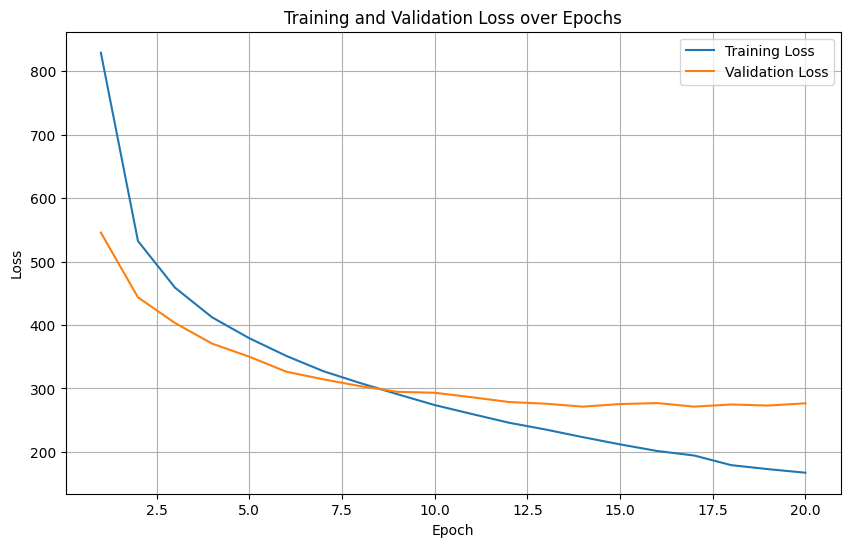

In [1]:
import matplotlib.pyplot as plt

# Extracting loss data from the training output
# This assumes the output format is consistent
output_lines = '''Epoch 1/20
Train Loss : 829.3988
Val Loss   : 545.6704
✔ Best model saved
----------------------------------------
Epoch 2/20
Train Loss : 532.4737
Val Loss   : 443.5985
✔ Best model saved
----------------------------------------
Epoch 3/20
Train Loss : 458.8370
Val Loss   : 403.0883
✔ Best model saved
----------------------------------------
Epoch 4/20
Train Loss : 412.0573
Val Loss   : 370.6028
✔ Best model saved
----------------------------------------
Epoch 5/20
Train Loss : 379.2077
Val Loss   : 350.0357
✔ Best model saved
----------------------------------------
Epoch 6/20
Train Loss : 351.2648
Val Loss   : 326.3551
✔ Best model saved
----------------------------------------
Epoch 7/20
Train Loss : 327.1198
Val Loss   : 314.3169
✔ Best model saved
----------------------------------------
Epoch 8/20
Train Loss : 308.3420
Val Loss   : 303.4950
✔ Best model saved
----------------------------------------
Epoch 9/20
Train Loss : 290.8464
Val Loss   : 294.5924
✔ Best model saved
----------------------------------------
Epoch 10/20
Train Loss : 273.7535
Val Loss   : 293.1259
✔ Best model saved
----------------------------------------
Epoch 11/20
Train Loss : 259.7235
Val Loss   : 286.1022
✔ Best model saved
----------------------------------------
Epoch 12/20
Train Loss : 245.9141
Val Loss   : 278.5648
✔ Best model saved
----------------------------------------
Epoch 13/20
Train Loss : 235.0692
Val Loss   : 275.8466
✔ Best model saved
----------------------------------------
Epoch 14/20
Train Loss : 223.0741
Val Loss   : 271.2222
✔ Best model saved
----------------------------------------
Epoch 15/20
Train Loss : 211.7434
Val Loss   : 275.3197
----------------------------------------
Epoch 16/20
Train Loss : 201.3068
Val Loss   : 276.8621
----------------------------------------
Epoch 17/20
Train Loss : 194.1619
Val Loss   : 271.2376
----------------------------------------
Epoch 18/20
Train Loss : 178.9544
Val Loss   : 274.6400
----------------------------------------
Epoch 19/20
Train Loss : 172.6104
Val Loss   : 272.9690
----------------------------------------
Epoch 20/20
Train Loss : 167.0210
Val Loss   : 276.4722
----------------------------------------'''

epochs = []
train_losses = []
val_losses = []

lines = output_lines.split('\n')
for i in range(len(lines)):
    if 'Epoch' in lines[i]:
        epoch_num = int(lines[i].split('/')[0].split(' ')[1])
        train_loss = float(lines[i+1].split(': ')[1])
        val_loss = float(lines[i+2].split(': ')[1])
        epochs.append(epoch_num)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

# Plotting the losses
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()